# Heat map of $\Delta^t(s_u)$ under $s_u$ with different SoP and AoP 

**The resluts here is the shift-1 version of "find_correct_metrics-all_model_raw.ipynb", i.e., old_[:-1]=new_[1:]**

In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import torch.nn.functional as F
from utils.utils_analyze import topk_entropy, top12_prob_diff,get_label_rank_practical
from tqdm import tqdm
import seaborn as sns
from utils.config_read import *
import pandas as pd
from scipy.stats import rankdata
# sns.set_theme()
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr,spearmanr

GAMMA_SOP = 0.5

def standard_score(tensor):
    mean = tensor.float().mean()
    std = tensor.float().std()
    return (tensor - mean) / std

def drop_zero_sop_rows(sft_results, sop_col="sop"):
    """
    Remove all rows with SOP == 0 from a pandas DataFrame.

    Args:
        sft_results: pandas.DataFrame
        sop_col: column name for SOP

    Returns:
        pandas.DataFrame
    """
    if sop_col not in sft_results.columns:
        raise KeyError(f"Column '{sop_col}' not found in DataFrame.")

    return sft_results[sft_results[sop_col] != 0].copy()

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def _to_numpy_1d(x):
    if x is None:
        return None
    if "torch" in str(type(x)):
        x = x.detach().cpu().numpy()
    x = np.asarray(x).reshape(-1)
    return x


def rank_normalize(x):
    """
    Convert x to [0, 1] percentile-like ranks.
    Ties are handled approximately by stable sorting order.
    """
    x = _to_numpy_1d(x)
    order = np.argsort(x, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(len(x), dtype=np.float64)
    if len(x) > 1:
        ranks /= (len(x) - 1)
    return ranks


def compute_binned_forgetting_heatmap(
    sop,
    aop,
    forgetting,
    n_bins=12,
    use_rank=False,
    x_range=None,
    y_range=None,
    min_count=1,
):
    """
    Bin SOP and AOP into a 2D grid, and compute mean forgetting in each bin.

    Args:
        sop: (N,)
        aop: (N,)
        forgetting: (N,)
        n_bins: number of bins per axis
        use_rank: if True, rank-normalize sop/aop into [0,1] before binning
        x_range: optional tuple (xmin, xmax) for raw-value binning
        y_range: optional tuple (ymin, ymax) for raw-value binning
        min_count: bins with count < min_count will be masked as NaN

    Returns:
        result: dict containing
            - mean_grid: (n_bins, n_bins), mean forgetting
            - count_grid: (n_bins, n_bins), sample counts
            - x_edges, y_edges
            - x_used, y_used
    """
    sop = _to_numpy_1d(sop)
    aop = _to_numpy_1d(aop)
    forgetting = _to_numpy_1d(forgetting)

    assert len(sop) == len(aop) == len(forgetting), "Inputs must have same length."

    valid = np.isfinite(sop) & np.isfinite(aop) & np.isfinite(forgetting)
    sop = sop[valid]
    aop = aop[valid]
    forgetting = forgetting[valid]

    if use_rank:
        x = rank_normalize(sop)
        y = rank_normalize(aop)
        x_edges = np.linspace(0.0, 1.0, n_bins + 1)
        y_edges = np.linspace(0.0, 1.0, n_bins + 1)
    else:
        x = sop
        y = aop

        if x_range is None:
            x_min, x_max = np.min(x), np.max(x)
        else:
            x_min, x_max = x_range

        if y_range is None:
            y_min, y_max = np.min(y), np.max(y)
        else:
            y_min, y_max = y_range

        # avoid zero-width bins
        if x_max == x_min:
            x_max = x_min + 1e-8
        if y_max == y_min:
            y_max = y_min + 1e-8

        x_edges = np.linspace(x_min, x_max, n_bins + 1)
        y_edges = np.linspace(y_min, y_max, n_bins + 1)

    # digitize into bin indices
    x_bin = np.digitize(x, x_edges) - 1
    y_bin = np.digitize(y, y_edges) - 1

    # include right edge in the last bin
    x_bin = np.clip(x_bin, 0, n_bins - 1)
    y_bin = np.clip(y_bin, 0, n_bins - 1)

    sum_grid = np.zeros((n_bins, n_bins), dtype=np.float64)
    count_grid = np.zeros((n_bins, n_bins), dtype=np.int64)

    for xb, yb, f in zip(x_bin, y_bin, forgetting):
        # convention: rows=y bins, cols=x bins, so plotting matches x horizontal, y vertical
        sum_grid[yb, xb] += f
        count_grid[yb, xb] += 1

    mean_grid = np.full((n_bins, n_bins), np.nan, dtype=np.float64)
    mask = count_grid >= min_count
    mean_grid[mask] = sum_grid[mask] / count_grid[mask]

    return {
        "mean_grid": mean_grid,
        "count_grid": count_grid,
        "x_edges": x_edges,
        "y_edges": y_edges,
        "x_used": x,
        "y_used": y,
    }


def plot_binned_forgetting_heatmaps(
    sop,
    aop,
    forgetting,
    n_bins=12,
    min_count=5,
    figsize=(12, 5),
):
    """
    Plot two heatmaps:
    1. raw SOP/AOP bins -> mean forgetting
    2. rank-normalized SOP/AOP bins -> mean forgetting
    Also plot count heatmaps for sanity check.
    """
    raw_res = compute_binned_forgetting_heatmap(
        sop=sop,
        aop=aop,
        forgetting=forgetting,
        n_bins=n_bins,
        use_rank=False,
        min_count=min_count,
    )

    rank_res = compute_binned_forgetting_heatmap(
        sop=sop,
        aop=aop,
        forgetting=forgetting,
        n_bins=n_bins,
        use_rank=True,
        min_count=min_count,
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ---- raw mean forgetting
    im0 = axes[0, 0].imshow(
        raw_res["mean_grid"],
        origin="lower",
        aspect="auto",
        extent=[
            raw_res["x_edges"][0], raw_res["x_edges"][-1],
            raw_res["y_edges"][0], raw_res["y_edges"][-1]
        ],
    )
    axes[0, 0].set_title("Mean Forgetting (Raw SOP/AOP bins)")
    axes[0, 0].set_xlabel("SOP")
    axes[0, 0].set_ylabel("AOP")
    plt.colorbar(im0, ax=axes[0, 0], label="Mean forgetting")

    # ---- raw counts
    im1 = axes[0, 1].imshow(
        raw_res["count_grid"],
        origin="lower",
        aspect="auto",
        extent=[
            raw_res["x_edges"][0], raw_res["x_edges"][-1],
            raw_res["y_edges"][0], raw_res["y_edges"][-1]
        ],
    )
    axes[0, 1].set_title("Bin Counts (Raw SOP/AOP bins)")
    axes[0, 1].set_xlabel("SOP")
    axes[0, 1].set_ylabel("AOP")
    plt.colorbar(im1, ax=axes[0, 1], label="Count")

    # ---- rank mean forgetting
    im2 = axes[1, 0].imshow(
        rank_res["mean_grid"],
        origin="lower",
        aspect="auto",
        extent=[0, 1, 0, 1],
    )
    axes[1, 0].set_title("Mean Forgetting (Rank-normalized bins)")
    axes[1, 0].set_xlabel("SOP rank")
    axes[1, 0].set_ylabel("AOP rank")
    plt.colorbar(im2, ax=axes[1, 0], label="Mean forgetting")

    # ---- rank counts
    im3 = axes[1, 1].imshow(
        rank_res["count_grid"],
        origin="lower",
        aspect="auto",
        extent=[0, 1, 0, 1],
    )
    axes[1, 1].set_title("Bin Counts (Rank-normalized bins)")
    axes[1, 1].set_xlabel("SOP rank")
    axes[1, 1].set_ylabel("AOP rank")
    plt.colorbar(im3, ax=axes[1, 1], label="Count")

    plt.tight_layout()
    plt.show()

    return raw_res, rank_res

In [53]:
MODEL = "Llama-3.2-3B-Instruct" #"Llama-3.2-3B" #"Qwen2.5-Math-7B-Instruct"#"Qwen2.5-3B-Instruct" #"Mistral-7B-v0.1"#"Qwen2.5-7B-Instruct"#
print(f'Model is {MODEL}')
#result_path_sft = f"/users/josren/SFT_vs_RL/results/sft_single_token_mmlu/{MODEL}/sft/updates_summary.parquet"
#result_path_sft = "/users/josren/SFT_vs_RL/results/sft_single_token_mmlu/updates_summary.parquet"
#result_path_sft = f"/users/josren/SFT_vs_RL/results/sft_single_token_mmlu_extra/{MODEL}/sft/updates_summary.parquet"
result_path_sft = f"/users/josren/SFT_vs_RL/results/sft_single_token_mmlu_change_sop_start/{MODEL}/sft/updates_summary.parquet"
sft_results = pd.read_parquet(result_path_sft)
sft_results = drop_zero_sop_rows(sft_results)

print(sft_results.keys())

Model is Llama-3.2-3B-Instruct
Index(['update_id', 'algo', 'sample_id', 'token_pos', 'sop', 'entropy',
       'aop_l2', 'aop_kl', 'f_avg_mean', 'f_ratio_mean',
       'f_avg_abstract_algebra', 'f_ratio_abstract_algebra',
       'f_avg_college_mathematics', 'f_ratio_college_mathematics',
       'f_avg_high_school_physics', 'f_ratio_high_school_physics',
       'f_avg_computer_security', 'f_ratio_computer_security',
       'f_avg_international_law', 'f_ratio_international_law', 'loss',
       'target_token_id'],
      dtype='object')


## Concrete examples of token's off-policy nature and their forgetting behavior

A bit hard to find consistent trends. Maybe it is just a statistical principle.

In [54]:
from IPython.display import display, HTML
import torch
import numpy as np
from scipy.stats import rankdata

def visualize_tokens_dual_quantile(tokenizer, labels, metrics, top_n=10, bottom_n=10):
    if torch.is_tensor(labels): labels = labels.detach().cpu().tolist()
    if torch.is_tensor(metrics): metrics = metrics.detach().cpu().numpy()
    else: metrics = np.array(metrics)

    tokens = tokenizer.convert_ids_to_tokens(labels)
    
    percentiles = rankdata(metrics, method='average') / len(metrics)
    
    top_threshold = 1.0 - (top_n / 100.0)
    bottom_threshold = bottom_n / 100.0

    html_elements = []

    for token, metric_val, p in zip(tokens, metrics, percentiles):
        display_text = tokenizer.convert_tokens_to_string([token])
        display_text = display_text.replace('\n', '<br/>')
        
        style = ""
        if p > top_threshold and top_n > 0:
            alpha = 0.2 + ((p - top_threshold) / (1.0 - top_threshold + 1e-9)) * 0.6
            style = (
                f"background-color: rgba(255, 0, 0, {alpha:.2f}); "
                f"border-bottom: 2px solid rgba(255, 0, 0, {alpha + 0.1:.2f}); "
            )
            
        elif p < bottom_threshold and bottom_n > 0:
            alpha = 0.2 + ((bottom_threshold - p) / (bottom_threshold + 1e-9)) * 0.6
            style = (
                f"background-color: rgba(0, 0, 255, {alpha:.2f}); "
                f"border-bottom: 2px solid rgba(0, 0, 255, {alpha + 0.1:.2f}); "
            )

        if style:
            style += "border-radius: 2px; padding: 0 1px;"
            html_elements.append(
                f'<span style="{style}" title="Value: {metric_val:.4f}\nPercentile: {p:.2%}">{display_text}</span>'
            )
        else:
            html_elements.append(f'<span>{display_text}</span>')
    
    display(HTML(f"""
        <div style="
            font-family: 'Segoe UI', 'Roboto', monospace; 
            line-height: 2.2; 
            padding: 20px; 
            background: #fff;
            white-space: pre-wrap;
            word-wrap: break-word;
            border: 1px solid #ddd;
            border-radius: 8px;
        ">{''.join(html_elements)}</div>
    """))

In [55]:
# from transformers import AutoTokenizer
# from datasets import load_dataset
# from utils.gsm8k_tokenizer import GSM8KTokenizerProcessor

# tokenizer = AutoTokenizer.from_pretrained(
#     'Qwen/Qwen3.5-0.8B',
#     padding_side="right",
#     truncation_side="right",
#     trust_remote_code=True,
#     #use_fast=False 
# )
# dataset = load_dataset("openai/gsm8k",'main',split="train")
# processor = GSM8KTokenizerProcessor(model_name_or_path='Qwen/Qwen3.5-0.8B',max_length=500)
# processed_dataset = processor.process_dataset(dataset)

In [56]:
# start_id = 0
# for i in range(10):
#     sample = processed_dataset[i]
#     labels = sample['labels']
#     valid_parts = labels[labels != -100]
#     end_id = start_id + len(valid_parts)
    
#     aop_l2 = sft_results['aop_l2'][start_id:end_id]
#     aop_kl = sft_results['aop_kl'][start_id:end_id]
#     sop = sft_results['sop'][start_id:end_id]
#     entropy = sft_results['entropy'][start_id:end_id]
#     f_ratio_mean = sft_results['f_avg_mean'][start_id:end_id]
#     if i == 0:
#         print(f'@@@@@@@@@ Question {i}:  @@@@@@@@@')
#         print('======= AOFP_L2 ==========')
#         visualize_tokens_dual_quantile(tokenizer, labels=valid_parts, metrics=aop_kl, top_n=5, bottom_n=5)
#         print('======= SOFP ==========')
#         visualize_tokens_dual_quantile(tokenizer, labels=valid_parts, metrics=sop, top_n=5, bottom_n=5)
#         # print('======= Forget ==========')
#         # print(visualize_tokens_dual_quantile(tokenizer, labels=valid_parts, metrics=f_ratio_mean, top_n=20, bottom_n=0))
    
#     start_id = end_id



In [57]:
# EXP_NAME = 'sft' #'rl_tmp1'#
# SFT_OR_RL = EXP_NAME.split('_')[0]
# raw_data = torch.load(f'{SCRATCH_PATH}{EXP_NAME}_logits.pt')
# loaded_data = raw_data[f'{SFT_OR_RL}_logits']
# loaded_label = raw_data[f'{SFT_OR_RL}_labels']

# N_sample = len(loaded_data)
# results = {}
# yprob_list = []
# prefix_list = []
# for i in range(50):
#     logits = loaded_data[i]
#     labels = loaded_label[i]
#     probs = F.softmax(logits, dim=-1)  # [L, V]
#     diff, top1_prob, top2_prob, yprob = top12_prob_diff(logits, labels)
#     yprob_list.append(yprob)
#     prefix = [yprob.mean()]
#     for j in range(yprob.shape[0]-1):
#         prefix.append(yprob[:j+1].sum() / (j+1))
#     prefix_list.append(torch.tensor(prefix))

#     # ------- Record low y_prob tokens 
#     print(f"============= The {i}-th Example ===============")
#     print(visualize_tokens_final(tokenizer, labels, yprob, THRES, base_color=(255,0,0)))

### Exp 1. See the correlations of these metrics

Looks that non of them are 100% correlated, i.e., the all provide some unique information

In [58]:
# fig, ax = plt.subplots(2, 3, figsize=(15, 8))
# XY_ARRAY = [('sop', 'aop_l2'),  ('sop', 'aop_kl'),   ('aop_l2', 'aop_kl'),
#             ('sop', 'entropy'), ('sop', 'f_ratio_mean'),  ('f_ratio_mean', 'f_avg_mean')]
# Y_LOG_LIST = []
# for i in range(2):
#     for j in range(3):
#         idx = i*3+j
#         XY = XY_ARRAY[idx]
#         ax[i][j].scatter(sft_results[XY[0]], sft_results[XY[1]], alpha=0.3,label='sft')
#         # ax[i][j].scatter(rl_results_rlt1[XY[0]], rl_results_rlt1[XY[1]], alpha=0.3,label='rl_tmp1')
#         # ax[i][j].scatter(rl_results_rlt07[XY[0]], rl_results_rlt07[XY[1]], alpha=0.3,label='rl_tmp07')
#         # ax[i][j].scatter(rl_results_rlt00[XY[0]], rl_results_rlt00[XY[1]], alpha=0.3,label='rl_greedy')
#         ax[i][j].set_xlabel(XY[0])
#         ax[i][j].set_ylabel(XY[1])
#         ax[i][j].legend(fontsize=16)
#         if idx in Y_LOG_LIST:
#             ax[i][j].set_yscale('log')

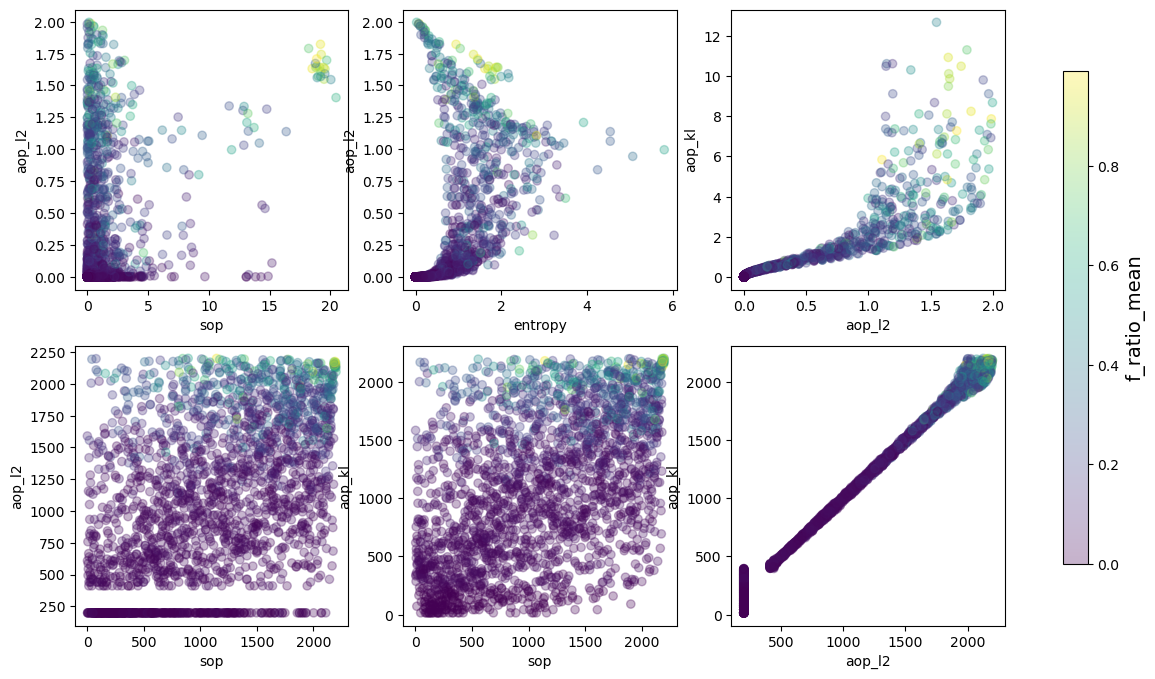

In [59]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
XY_ARRAY = [('sop', 'aop_l2'),  ('entropy', 'aop_l2'),   ('aop_l2', 'aop_kl'),
            ('sop', 'aop_l2'),  ('sop', 'aop_kl'),   ('aop_l2', 'aop_kl'),]
            #('sop', 'entropy'), ('sop', 'f_ratio_mean'),  ('f_ratio_mean', 'f_avg_mean')]
Y_LOG_LIST = []
for i in range(2):
    for j in range(3):
        idx = i*3+j
        XY = XY_ARRAY[idx]
        if i==0:
            sc = ax[i][j].scatter((sft_results[XY[0]]), (sft_results[XY[1]]), alpha=0.3,label='sft',c=sft_results['f_ratio_mean'],cmap="viridis")
        else:
            sc = ax[i][j].scatter(rankdata(sft_results[XY[0]]), rankdata(sft_results[XY[1]]), alpha=0.3,label='sft',c=sft_results['f_ratio_mean'],cmap="viridis")
        # ax[i][j].scatter(rl_results_rlt1[XY[0]], rl_results_rlt1[XY[1]], alpha=0.3,label='rl_tmp1')
        # ax[i][j].scatter(rl_results_rlt07[XY[0]], rl_results_rlt07[XY[1]], alpha=0.3,label='rl_tmp07')
        # ax[i][j].scatter(rl_results_rlt00[XY[0]], rl_results_rlt00[XY[1]], alpha=0.3,label='rl_greedy')
        ax[i][j].set_xlabel(XY[0])
        ax[i][j].set_ylabel(XY[1])
        if idx in Y_LOG_LIST:
            ax[i][j].set_yscale('log')
cbar = fig.colorbar(sc, ax=ax.ravel().tolist(), shrink=0.8)
cbar.set_label('f_ratio_mean', fontsize=14)

plt.show()

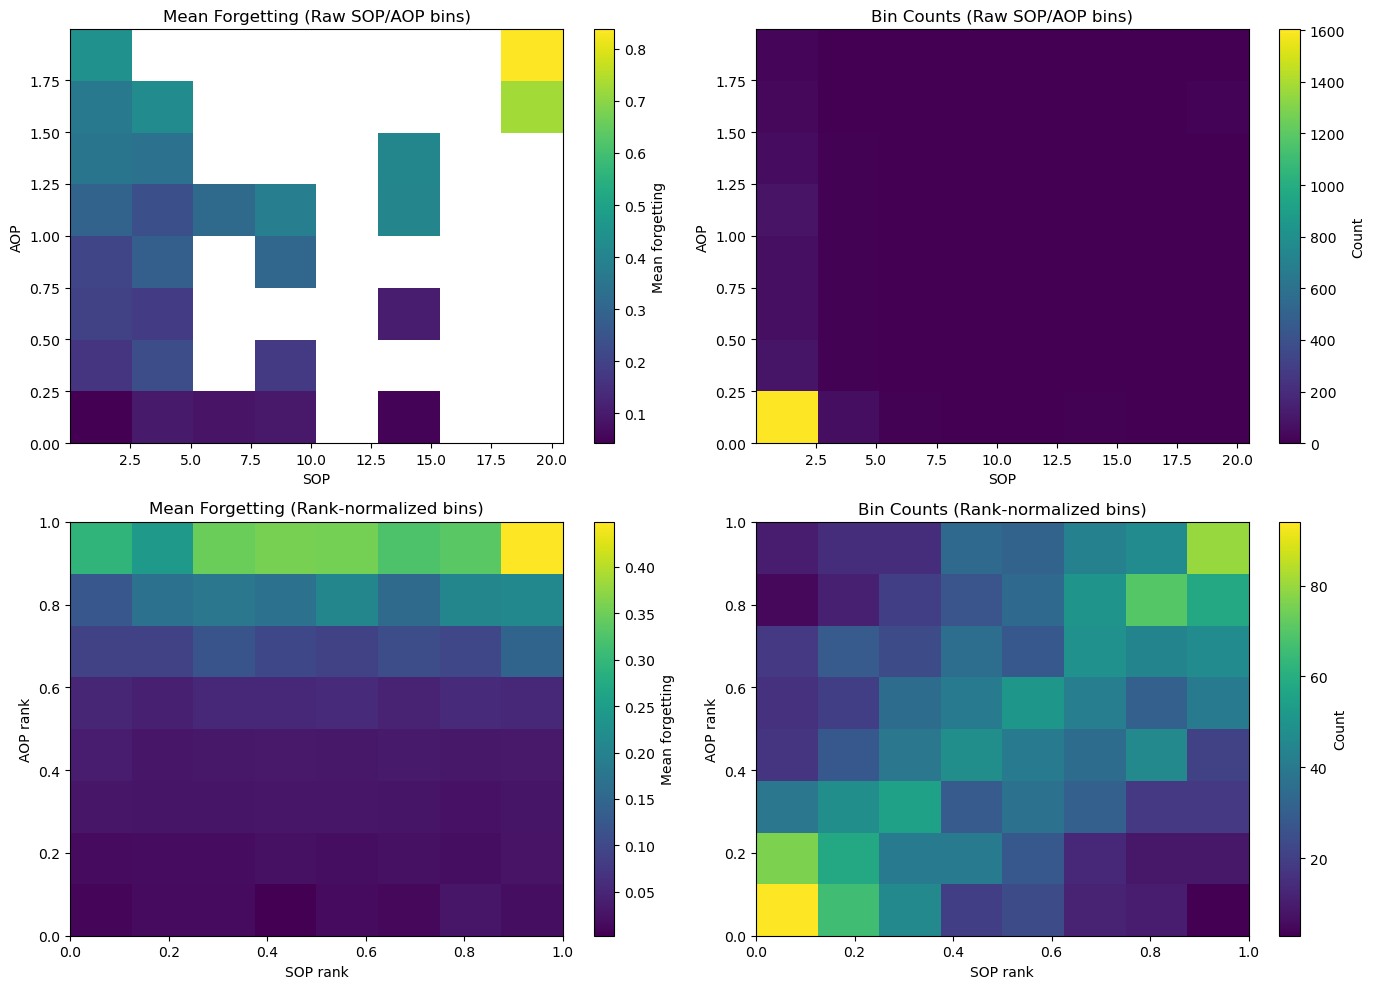

In [60]:
raw_res, rank_res = plot_binned_forgetting_heatmaps(
    sop=sft_results['sop'],
    aop=sft_results['aop_l2'],
    forgetting=abs(sft_results['f_ratio_mean']),
    n_bins=8,
    min_count=2,
)

In [61]:
import numpy as np
import pandas as pd
from IPython.display import display


def _to_numpy_1d(x):
    if "torch" in str(type(x)):
        x = x.detach().cpu().numpy()
    return np.asarray(x).reshape(-1)


def rank_normalize(x):
    x = _to_numpy_1d(x)
    order = np.argsort(x, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(len(x), dtype=np.float64)
    if len(x) > 1:
        ranks /= (len(x) - 1)
    return ranks


def summarize_3x3_table(
    sop,
    aop,
    forgetting,
    use_rank=True,
    value_name="mean_forgetting",
    digits=4,
):
    """
    Return:
        mean_df: 3x3 DataFrame of mean forgetting
        count_df: 3x3 DataFrame of counts
        latex_mean: LaTeX string for mean table
        latex_count: LaTeX string for count table
        detail_df: long-form DataFrame
    """
    sop = _to_numpy_1d(sop)
    aop = _to_numpy_1d(aop)
    forgetting = _to_numpy_1d(forgetting)

    assert len(sop) == len(aop) == len(forgetting), "Inputs must have same length."

    valid = np.isfinite(sop) & np.isfinite(aop) & np.isfinite(forgetting)
    sop = sop[valid]
    aop = aop[valid]
    forgetting = forgetting[valid]

    if use_rank:
        x = rank_normalize(sop)
        y = rank_normalize(aop)
        x_edges = np.array([0.0, 1/3, 2/3, 1.0])
        y_edges = np.array([0.0, 1/3, 2/3, 1.0])
    else:
        x = sop
        y = aop
        x_edges = np.quantile(x, [0.0, 1/3, 2/3, 1.0])
        y_edges = np.quantile(y, [0.0, 1/3, 2/3, 1.0])

    labels = ["low", "mid", "high"]
    rows = []

    for i in range(3):
        for j in range(3):
            x_lo, x_hi = x_edges[i], x_edges[i + 1]
            y_lo, y_hi = y_edges[j], y_edges[j + 1]

            if i < 2:
                x_mask = (x >= x_lo) & (x < x_hi)
            else:
                x_mask = (x >= x_lo) & (x <= x_hi)

            if j < 2:
                y_mask = (y >= y_lo) & (y < y_hi)
            else:
                y_mask = (y >= y_lo) & (y <= y_hi)

            mask = x_mask & y_mask
            n = int(mask.sum())
            mean_f = float(np.mean(forgetting[mask])) if n > 0 else np.nan

            rows.append({
                "sop_group": labels[i],
                "aop_group": labels[j],
                "count": n,
                value_name: mean_f,
            })

    detail_df = pd.DataFrame(rows)

    mean_df = detail_df.pivot(
        index="aop_group",
        columns="sop_group",
        values=value_name
    ).reindex(index=labels, columns=labels)

    count_df = detail_df.pivot(
        index="aop_group",
        columns="sop_group",
        values="count"
    ).reindex(index=labels, columns=labels)

    mean_df = mean_df.round(digits)

    latex_mean = mean_df.to_latex(
        float_format=lambda x: f"{x:.{digits}f}",
        caption=f"3x3 grouped table of {value_name}",
        label=f"tab:{value_name}_3x3",
        na_rep="--"
    )

    latex_count = count_df.to_latex(
        caption="3x3 grouped table of sample counts",
        label="tab:count_3x3",
        na_rep="--"
    )

    return mean_df, count_df, latex_mean, latex_count, detail_df


def display_3x3_tables(
    sop,
    aop,
    forgetting,
    use_rank=True,
    value_name="mean_forgetting",
    digits=4,
):
    mean_df, count_df, latex_mean, latex_count, detail_df = summarize_3x3_table(
        sop=sop,
        aop=aop,
        forgetting=forgetting,
        use_rank=use_rank,
        value_name=value_name,
        digits=digits,
    )

    title = "Rank-based 3x3 grouping" if use_rank else "Raw-value 3x3 grouping"
    print(title)
    print("\nMean forgetting table:")
    display(mean_df)

    print("Count table:")
    display(count_df)

    return {
        "mean_df": mean_df,
        "count_df": count_df,
        "latex_mean": latex_mean,
        "latex_count": latex_count,
        "detail_df": detail_df,
    }

In [62]:
res = display_3x3_tables(
    sop=sft_results['sop'],
    aop=sft_results['aop_l2'],
    forgetting=sft_results['f_ratio_mean'],
    use_rank=True,
    value_name="mean_forgetting",
    digits=4,
)

res = display_3x3_tables(
    sop=sft_results['sop'],
    aop=sft_results['aop_l2'],
    forgetting=sft_results['f_avg_mean'],
    use_rank=True,
    value_name="mean_forgetting",
    digits=4,
)
# print(res["latex_mean"])
# print(res["latex_count"])

Rank-based 3x3 grouping

Mean forgetting table:


sop_group,low,mid,high
aop_group,,,
low,0.0179,0.0197,0.0240
mid,0.0449,0.0447,0.0477
high,0.1685,0.2337,0.2584


Count table:


sop_group,low,mid,high
aop_group,,,
low,448,205,81
mid,188,290,255
high,98,238,398


Rank-based 3x3 grouping

Mean forgetting table:


sop_group,low,mid,high
aop_group,,,
low,0.0013,0.0015,0.0018
mid,0.0038,0.0040,0.0043
high,0.0039,0.0595,0.0886


Count table:


sop_group,low,mid,high
aop_group,,,
low,448,205,81
mid,188,290,255
high,98,238,398


In [127]:
sft_results.keys()

Index(['update_id', 'algo', 'sample_id', 'token_pos', 'sop', 'entropy',
       'aop_l2', 'aop_kl', 'f_avg_mean', 'f_ratio_mean',
       'f_avg_abstract_algebra', 'f_ratio_abstract_algebra',
       'f_avg_college_mathematics', 'f_ratio_college_mathematics', 'loss',
       'target_token_id'],
      dtype='object')

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_binned_trend(df, x_key, y_key, n_bins=10, use_rank=True, title=None):
    """
    参数:
    - df: DataFrame 数据源
    - x_key: 自变量列名
    - y_key: 因变量列名
    - n_bins: 分桶数量
    - use_rank: 
        True  -> 等频分桶 (Rank-based/Quantile)，每个桶样本量相同；
        False -> 等宽分桶 (Value-based/Interval)，将 X 的最大最小值等分。
    """
    # 浅拷贝一份数据，避免修改原始 DataFrame
    data = df[[x_key, y_key]].copy()
    
    # 1. 核心逻辑切换：分桶策略
    if use_rank:
        # qcut 是基于 Rank 的分位点切分
        data['bin'] = pd.qcut(data[x_key], q=n_bins, duplicates='drop')
        strategy_label = "Rank-based (Equal Frequency)"
    else:
        # cut 是基于数值绝对范围的等长切分
        data['bin'] = pd.cut(data[x_key], bins=n_bins)
        strategy_label = "Value-based (Equal Width)"
    
    # 2. 统计计算
    stats = data.groupby('bin').agg({
        x_key: 'mean',
        y_key: ['mean', 'std', 'count']
    })
    stats.columns = ['x_center', 'y_mean', 'y_std', 'count']
    stats = stats.reset_index().dropna() # 排除可能存在的空桶
    
    # 计算标准误 (SEM)
    stats['sem'] = stats['y_std'] / np.sqrt(stats['count'])
    
    # 3. 可视化
    plt.figure(figsize=(9, 5), dpi=100)
    
    # 绘制带误差阴影的折线
    plt.plot(stats['x_center'], stats['y_mean'], marker='o', label=f'Mean {y_key}')
    plt.fill_between(stats['x_center'], 
                     stats['y_mean'] - stats['sem'], 
                     stats['y_mean'] + stats['sem'], 
                     alpha=0.2, label='$\pm$ SEM')
    
    # 4. 图表修饰
    xlabel_suffix = "(Quantile Center)" if use_rank else "(Value Center)"
    plt.xlabel(f'{x_key} {xlabel_suffix}', fontsize=11)
    plt.ylabel(f'Mean {y_key}', fontsize=11)
    
    full_title = title if title else f'Trend: {y_key} vs {x_key}\nStrategy: {strategy_label}'
    plt.title(full_title, fontsize=13)
    
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    
    return stats

# --- 使用示例 ---
# 1. 按 Rank 分桶 (常用，能看到整体趋势，不受极值干扰)
# stats_rank = plot_binned_trend(sft_results, 'aop_l2', 'f_ratio_mean', use_rank=True)

# 2. 按 绝对值 分桶 (当你想看 aop_l2 在特定数值区间表现时使用)
# stats_val = plot_binned_trend(sft_results, 'aop_l2', 'f_ratio_mean', use_rank=False)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_forgetting_distribution(df, sop_key, aop_key, forget_key, n_percent=10):
    """
    逆向分析：提取遗忘程度最大的 top n% 样本，观察其 SOP 和 AOP 的分位数分布。
    
    参数:
    - df: 原始 DataFrame
    - sop_key: SOP 对应的列名
    - aop_key: AOP 对应的列名
    - forget_key: 遗忘得分的列名 (用于筛选 top 样本)
    - n_percent: 筛选前百分之多少的遗忘样本 (0-100)
    """
    # 1. 计算全量数据中 SOP 和 AOP 的百分位秩 (Percentile Rank)
    # rank(pct=True) 将数值转换为 0.0 到 1.0 之间的分位数
    plot_df = df.copy()
    plot_df['sop_percentile'] = plot_df[sop_key].rank(pct=True)
    plot_df['aop_percentile'] = plot_df[aop_key].rank(pct=True)
    
    # 2. 筛选遗忘程度最高的 top n% 样本
    # 先按遗忘程度降序排列
    threshold_value = plot_df[forget_key].quantile(1 - n_percent/100)
    top_forget_samples = plot_df[plot_df[forget_key] >= threshold_value]
    
    # 3. 绘图
    plt.figure(figsize=(7, 7), dpi=100)
    
    # 绘制散点
    plt.scatter(top_forget_samples['sop_percentile'], 
                top_forget_samples['aop_percentile'], 
                alpha=0.5, s=15, color='crimson', label=f'Top {n_percent}% Forgetting')
    
    # 绘制辅助线：分位数的中位线 (0.5, 0.5)
    plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
    
    # 4. 图表修饰
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.xlabel(f'{sop_key} Percentile (in all data)', fontsize=12)
    plt.ylabel(f'{aop_key} Percentile (in all data)', fontsize=12)
    
    plt.title(f'Feature Distribution of Most Forgotten Samples (Top {n_percent}%)\n'
              f'Metric: {forget_key}', fontsize=13)
    
    # 计算落在右上角(双高区域)的样本比例，增加学术说服力
    both_high = top_forget_samples[(top_forget_samples['sop_percentile'] > 0.5) & 
                                   (top_forget_samples['aop_percentile'] > 0.5)]
    ratio = len(both_high) / len(top_forget_samples) * 100
    
    plt.annotate(f'{ratio:.1f}% samples are in Top-Right quadrant', 
                 xy=(0.55, 0.95), fontsize=10, color='darkred', fontweight='bold')
    
    plt.grid(True, linestyle=':', alpha=0.3)
    plt.legend(loc='lower right')
    plt.tight_layout()
    
    return top_forget_samples

# --- 使用示例 ---
# df_top = plot_forgetting_distribution(sft_results, 
#                                       sop_key='sop_val', 
#                                       aop_key='aop_l2', 
#                                       forget_key='f_ratio_mean', 
#                                       n_percent=10)

In [64]:
f"meta-llama/{MODEL}"

'meta-llama/Llama-3.2-3B-Instruct'

In [65]:

# MODEL ="Qwen2.5-7B-Instruct"#"Qwen3.5-0.8B" # "Qwen2.5-1.5B"#"Llama-3.2-3B-Instruct" #"Qwen2.5-Math-7B-Instruct"# "Mistral-7B-v0.1"#
# print(f'Model is {MODEL}')
# result_path_sft = f"/users/josren/SFT_vs_RL/results/sft_single_token_mmlu/{MODEL}/sft/updates_summary.parquet"
# #result_path_sft = "/users/josren/SFT_vs_RL/results/sft_single_token_mmlu/updates_summary.parquet"
# #result_path_sft = f"/users/josren/SFT_vs_RL/results/sft_single_token_mmlu_extra/{MODEL}/sft/updates_summary.parquet"
# #result_path_sft = "/users/josren/SFT_vs_RL/results/sft_single_token_mmlu_extra/Llama-3.2-3B-Instruct/sft/updates_summary.parquet"
# sft_results = pd.read_parquet(result_path_sft)
# #sft_results = drop_zero_sop_rows(sft_results)

# tokenizer = AutoTokenizer.from_pretrained(
#     f"Qwen/{MODEL}",
#     padding_side="right",
#     truncation_side="right",
#     trust_remote_code=True,
#     #use_fast=False 
# )

# print(sft_results.keys())

In [66]:
# stats1 = plot_binned_trend(sft_results, x_key='aop_l2', y_key='f_ratio_mean',n_bins=10)

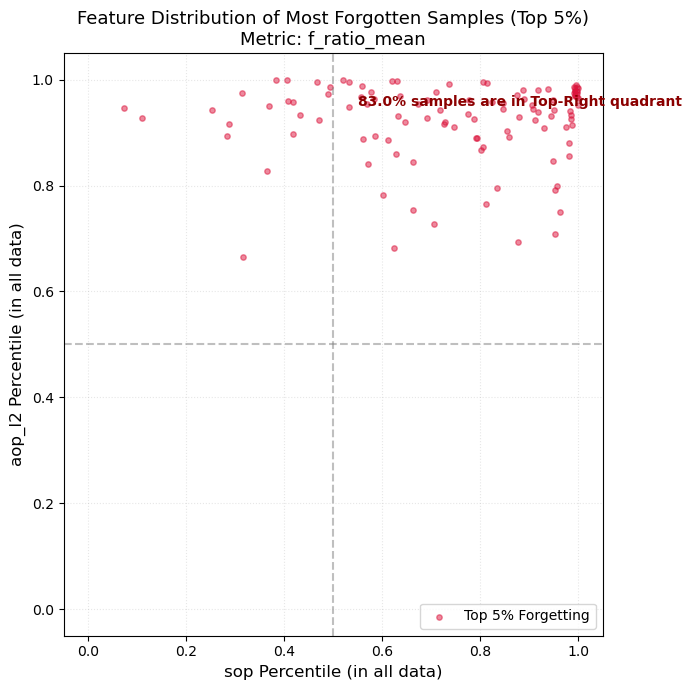

In [67]:
df_top = plot_forgetting_distribution(sft_results, sop_key='sop', aop_key='aop_l2', forget_key='f_ratio_mean', n_percent=5)

In [35]:
(sft_results['sop']==0).sum()

np.int64(0)

In [68]:
forget_key = 'f_ratio_mean'
sop_key = 'sop'  # 假设您的 SOP 列名为 'sop_val'
aop_key = 'aop_l2'   # 假设您的 AOP 列名为 'aop_l2'

# 2. 计算 Top 1% 的阈值
# 使用 quantile(0.99) 找到处于 99% 分位线以上的数值
threshold_1pct = sft_results[forget_key].quantile(0.99)

# 3. 筛选并按遗忘程度降序排列
top_1_percent_df = sft_results[sft_results[forget_key] >= threshold_1pct].sort_values(by=forget_key, ascending=False)

# 4. 为了更有学术深度，计算这些 Top 1% 样本在 SOP 和 AOP 上的平均排名（Percentile Rank）
# 这能告诉我们：最容易被遗忘的 token，其 SOP/AOP 是否普遍偏高
sop_rank_avg = sft_results[sop_key].rank(pct=True).loc[top_1_percent_df.index].mean()
aop_rank_avg = sft_results[aop_key].rank(pct=True).loc[top_1_percent_df.index].mean()

print(f"--- Top 1% Forgetting Analysis Report ---")
print(f"Minimum {forget_key} in Top 1%: {threshold_1pct:.4f}")
print(f"Number of tokens identified: {len(top_1_percent_df)}")
print(f"Average SOP Percentile Rank of these tokens: {sop_rank_avg:.2%}")
print(f"Average AOP Percentile Rank of these tokens: {aop_rank_avg:.2%}")
print(f"\nTop 20 most forgotten tokens and their scores:")

# 5. 展示前 20 个样本
def get_token_text(tid):
    try:
        # convert_ids_to_tokens 返回的是 token 原始形式（含 ## 或   等前缀）
        # 如果您想要更干净的文本，可以使用 tokenizer.decode([tid])
        return tokenizer.decode(int(tid))
    except Exception:
        return "Unknown"

# 1. 转换 ID 为文本
top_1_percent_df['token_text'] = top_1_percent_df['target_token_id'].apply(get_token_text)

# 2. 重新排列列顺序，方便观察对照
display_cols = ['token_text', forget_key, sop_key, aop_key, 'entropy', 'target_token_id']

# 3. 展示前 20 个
top_1_percent_df[display_cols].head(50)
#top_1_percent_df[[forget_key, sop_key, aop_key,'entropy',"target_token_id"]].head(20)

--- Top 1% Forgetting Analysis Report ---
Minimum f_ratio_mean in Top 1%: 0.7400
Number of tokens identified: 23
Average SOP Percentile Rank of these tokens: 84.27%
Average AOP Percentile Rank of these tokens: 95.80%

Top 20 most forgotten tokens and their scores:


,token_text,f_ratio_mean,sop,aop_l2,entropy,target_token_id
1980,tuning,0.990,18.873213,1.708435,1.450709,39972
764,Null,0.985,1.633180,1.107945,2.822659,3174
696,mer,0.970,0.281557,1.985541,0.078205,1134
1061,mel,0.960,18.496233,1.632194,1.617033,10267
1462,en,0.950,19.185389,1.823052,0.943447,644
1317,_quote,0.930,19.444498,1.640149,1.866862,43727
285,_N,0.920,19.250587,1.743580,1.351693,1548
1073,ff,0.870,2.319109,1.407586,1.363656,529
765,Russia,0.870,18.872864,1.652056,1.704892,8100
0,N,0.860,19.559839,1.629612,1.687736,45


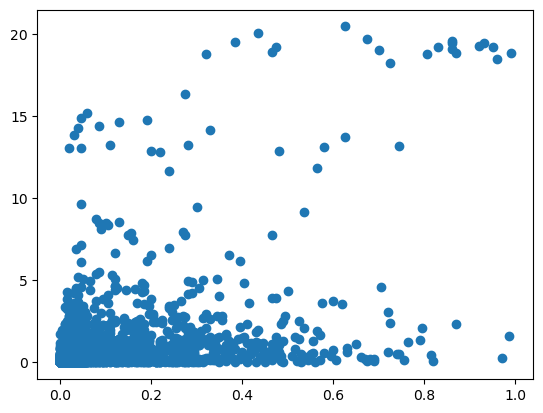

In [69]:
plt.scatter(sft_results['f_ratio_mean'][:],sft_results['sop'][:])

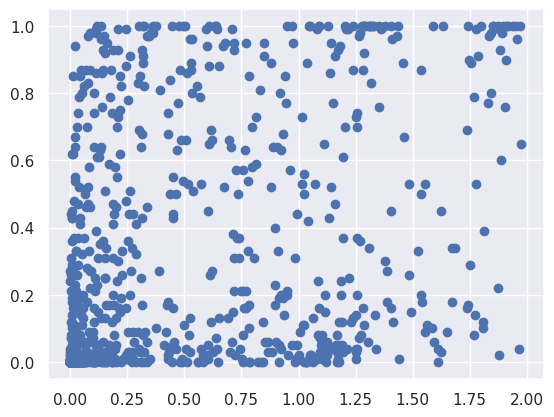

In [21]:
plt.scatter(sop_aop_results['aop_l2'], sop_aop_results['f_ratio_mean'])

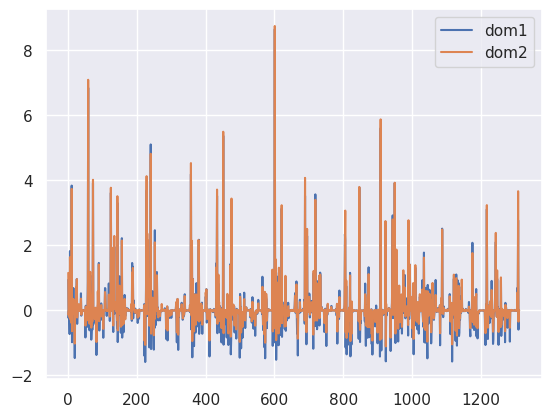

In [12]:
plt.plot(sop_aop_results['f_avg_abstract_algebra'],label='dom1')
plt.plot(sop_aop_results['f_avg_college_mathematics'],label='dom2')
plt.legend()

In [44]:
sop_aop_results['f_ratio_abstract_algebra']

0     0.89
1     0.02
2     0.00
3     0.01
4     0.25
      ... 
56    0.14
57    0.98
58    1.00
59    0.63
60    0.00
Name: f_ratio_abstract_algebra, Length: 61, dtype: float64

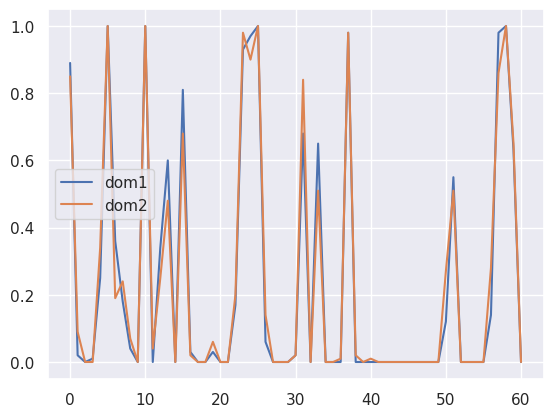

In [45]:
plt.plot(sop_aop_results['f_ratio_abstract_algebra'],label='dom1')
plt.plot(sop_aop_results['f_ratio_college_mathematics'],label='dom2')
plt.legend()

In [25]:
KEY = "entropy"
old_ = np.array(sft_results[KEY][:61])
new_ = np.array(sop_aop_results[KEY])

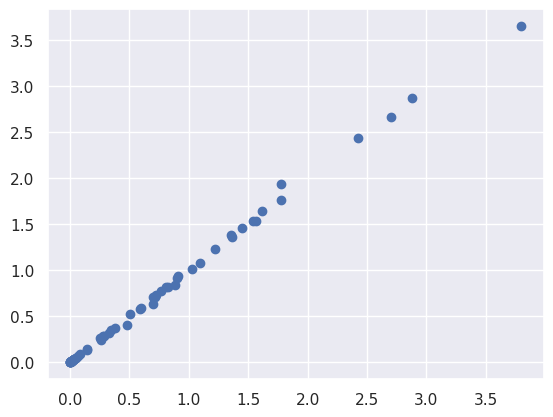

In [26]:
plt.scatter(old_[:-1],new_[1:])